In [138]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
# importing missing values csv
df = pd.read_csv('missingvalue.csv')

In [140]:
df.head()

,gender,math score,reading score,writing score,Placement Score,placement offer count,Region
0,female,72,72,74.0,78.0,1,Pune
1,female,69,90,88.0,NaN,2,na
2,female,90,95,93.0,74.0,2,Nashik
3,male,47,57,NaN,78.0,1,Na
4,male,na,78,75.0,81.0,3,Pune


In [141]:
# get dimensions
df.shape

(9, 7)

In [142]:
# get statistical analysis
df.describe()

,writing score,Placement Score,placement offer count
count,8.000000,8.000000,9.000000
mean,77.000000,62.125000,1.777778
std,13.416408,23.295846,1.201850
min,52.000000,12.000000,0.000000
25%,72.250000,53.500000,1.000000
50%,76.500000,72.000000,2.000000
75%,88.250000,78.000000,2.000000
max,93.000000,81.000000,4.000000


In [143]:
# Replace the Null values with proper Nan
df = df.replace(['Na', 'na'], np.nan)

In [144]:
# Count null values
df.isnull().sum()

gender                   0
math score               2
reading score            1
writing score            1
Placement Score          1
placement offer count    0
Region                   4
dtype: int64

In [145]:
# Print data type of each column
df.dtypes

gender                    object
math score                object
reading score             object
writing score            float64
Placement Score          float64
placement offer count      int64
Region                    object
dtype: object

In [146]:
# Fill null values with mean
df['writing score'].fillna(df['writing score'].mean(), inplace = True)
df['writing score'].isnull().sum()

0

In [147]:
# Fill null values with mean
df['Placement Score'].fillna(df['Placement Score'].mean(), inplace = True)
df['Placement Score'].isnull().sum()

0

In [148]:
# Filling with mode
df['Region'].fillna(df['Region'].mode()[0], inplace = True)
df['Region'].isnull().sum()

0

In [149]:
# First convert the object type into numeric
df['reading score'] = pd.to_numeric(df['reading score'], errors='coerce')

# Fill with mean
df['reading score'].fillna(df['reading score'].mean(), inplace = True)
df['reading score'].isnull().sum()

0

In [150]:
df['math score'] = pd.to_numeric(df['math score'], errors='coerce')
df['math score'].fillna(df['math score'].mean(), inplace = True)
df['math score'].isnull().sum()

0

In [151]:
df

,gender,math score,reading score,writing score,Placement Score,placement offer count,Region
0,female,72.000000,72.00,74.0,78.000,1,Pune
1,female,69.000000,90.00,88.0,62.125,2,Pune
2,female,90.000000,95.00,93.0,74.000,2,Nashik
3,male,47.000000,57.00,77.0,78.000,1,Pune
4,male,52.285714,78.00,75.0,81.000,3,Pune
5,female,71.000000,72.25,78.0,70.000,4,Pune
6,male,12.000000,44.00,52.0,12.000,2,Nashik
7,male,52.285714,65.00,67.0,49.000,1,Pune
8,male,5.000000,77.00,89.0,55.000,0,Pune


In [152]:
# Outlier detection can be done using
# 1) z-score
# 2) Box Plot
# 3) IQR
# 4) Scatter Plot

In [153]:
df = pd.read_csv('outliers.csv')

In [154]:
df.head()

,math score,reading score,writing score,placement score,placement offer count,club join year
0,80,68,70,89,3,2019
1,71,61,85,91,3,2019
2,79,16,87,77,2,2018
3,61,77,74,76,2,2020
4,78,71,67,90,3,2019


In [155]:
df.shape

(29, 6)

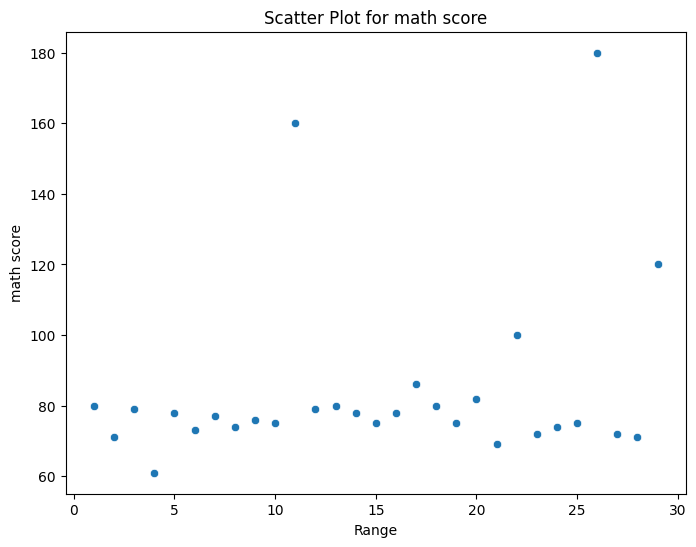

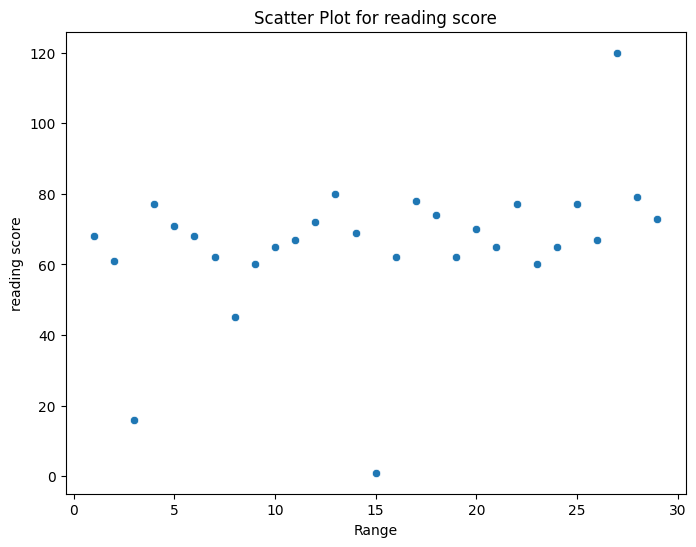

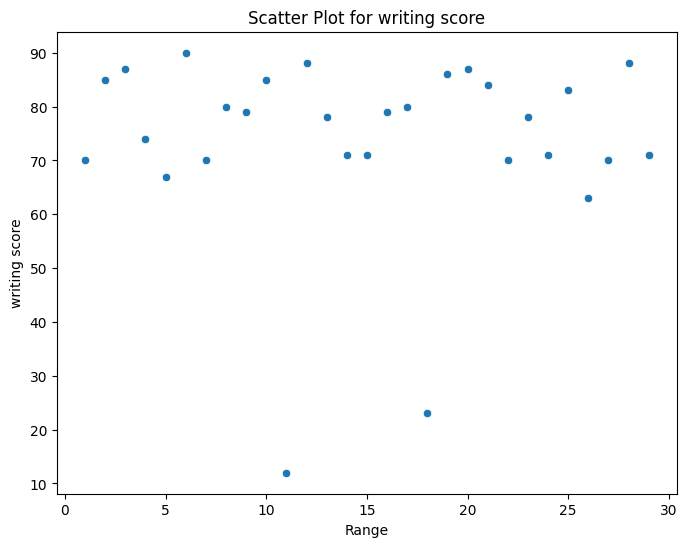

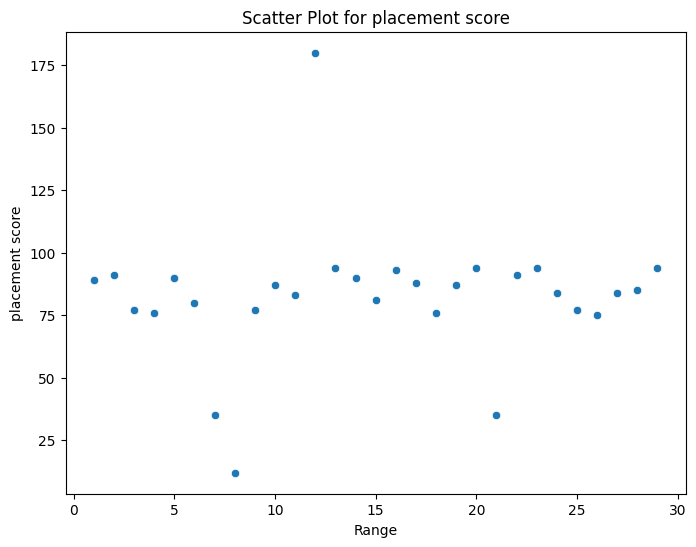

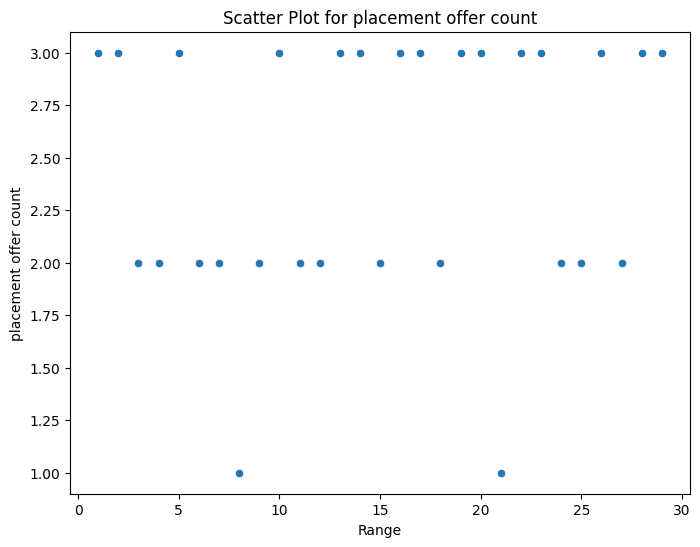

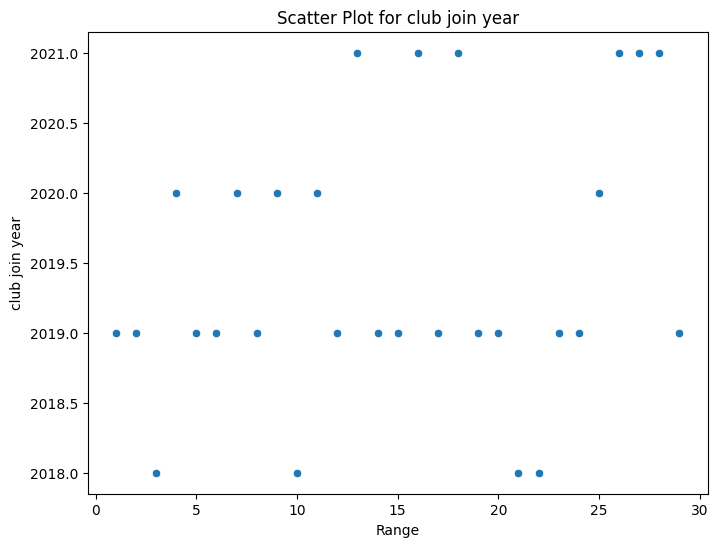

In [156]:
for column_name in df.columns:
    # set figure size    
    plt.figure(figsize=(8, 6))

    # calculate range
    df['range'] = range(1, len(df[column_name]) + 1)

    # prepare scatter plot
    sns.scatterplot(data=df, x=df["range"], y=df[column_name])
    plt.title(f"Scatter Plot for {column_name}")
    plt.xlabel('Range')
    plt.ylabel(column_name)
    plt.show()

df.drop('range', axis=1, inplace=True)

In [157]:
# calculate Q1
Q1 = df.quantile(0.25)

# calculate Q3
Q3 = df.quantile(0.75)

print(f'Q1: {Q1}\n')
print(f'Q3: {Q3}\n')

# Calculate IQR
IQR = Q3 - Q1
print(f'IQR: {IQR}\n')

# Calculate upper and lower bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Lower Bound: {lower_bound}\n')
print(f'Upper Bound: {upper_bound}\n')

for column in df.columns:
    # Identify rows where the value is outside the bounds
    outliers = df[(df[column] < lower_bound[column]) | (df[column] > upper_bound[column])][column]
    
    if not outliers.empty:
        print(f"Outliers in '{column}':")
        print(outliers.to_string())
        print("-" * 20)
    else:
        print(f"No outliers in '{column}'")
        print("-" * 20)

Q1: math score                 74.0
reading score              62.0
writing score              70.0
placement score            77.0
placement offer count       2.0
club join year           2019.0
Name: 0.25, dtype: float64

Q3: math score                 80.0
reading score              74.0
writing score              85.0
placement score            91.0
placement offer count       3.0
club join year           2020.0
Name: 0.75, dtype: float64

IQR: math score                6.0
reading score            12.0
writing score            15.0
placement score          14.0
placement offer count     1.0
club join year            1.0
dtype: float64

Lower Bound: math score                 65.0
reading score              44.0
writing score              47.5
placement score            56.0
placement offer count       0.5
club join year           2017.5
dtype: float64

Upper Bound: math score                 89.0
reading score              92.0
writing score             107.5
placement score      

(array([1, 2, 3, 4]),
 [Text(1, 0, 'math score'),
  Text(2, 0, 'reading score'),
  Text(3, 0, 'writing score'),
  Text(4, 0, 'placement score')])

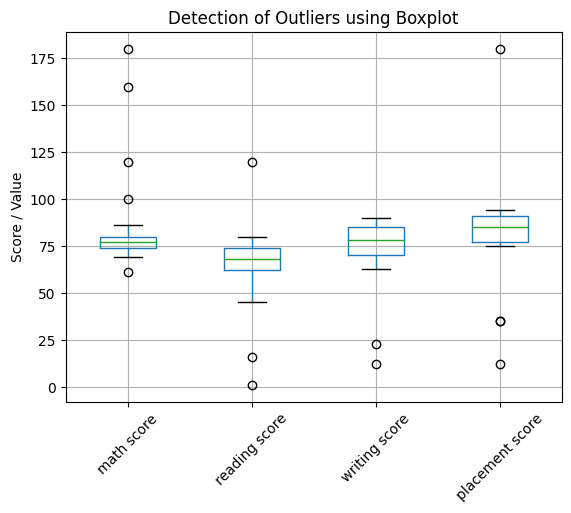

In [158]:
df1 = df.drop(['placement offer count', 'club join year'], axis=1)
df1.boxplot()
plt.title('Detection of Outliers using Boxplot')
plt.ylabel('Score / Value')
plt.xticks(rotation=45)

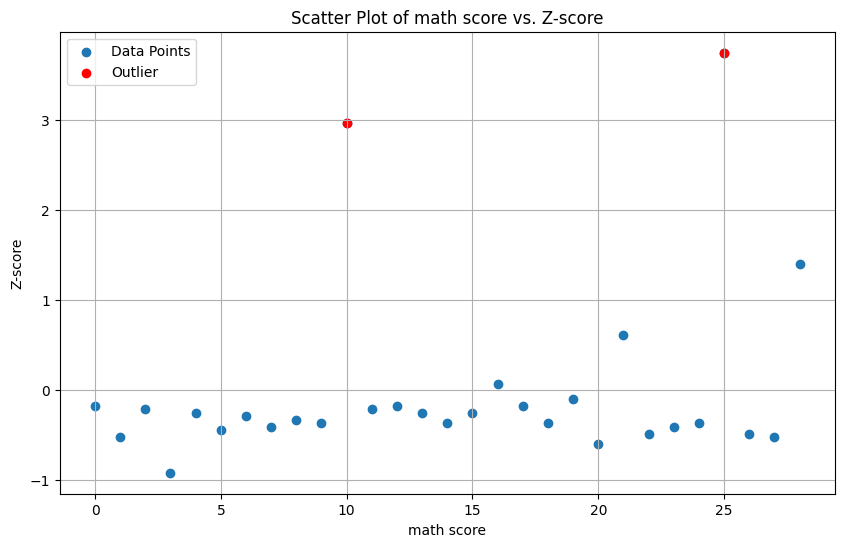

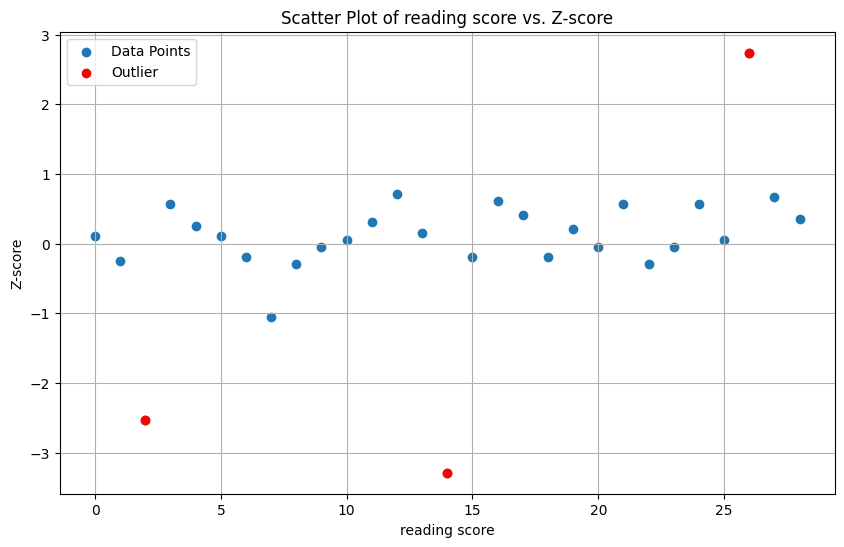

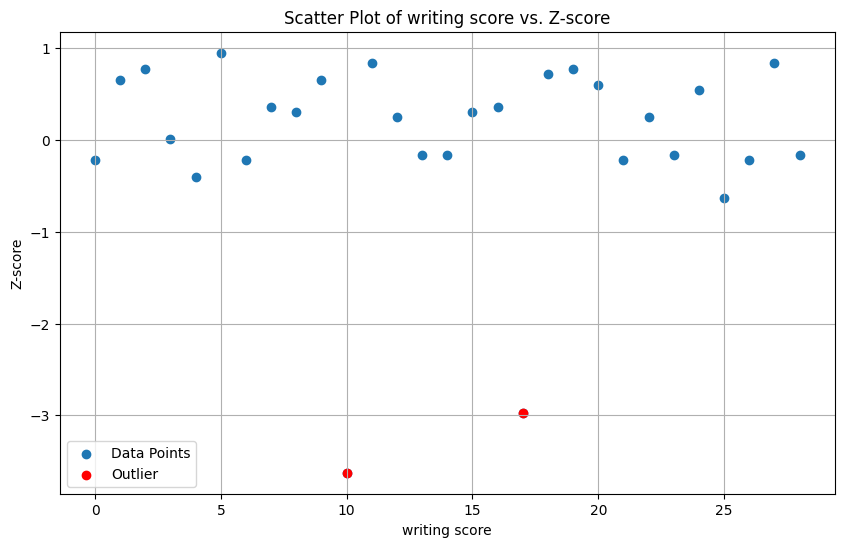

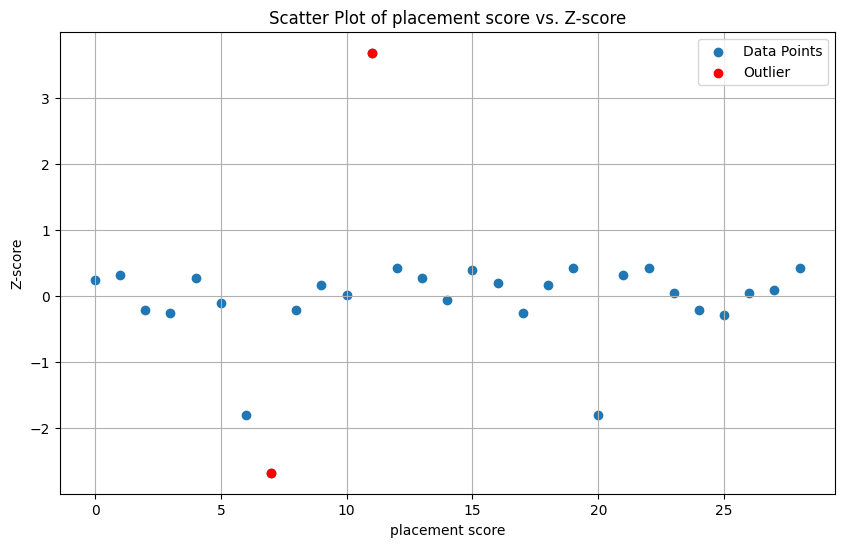

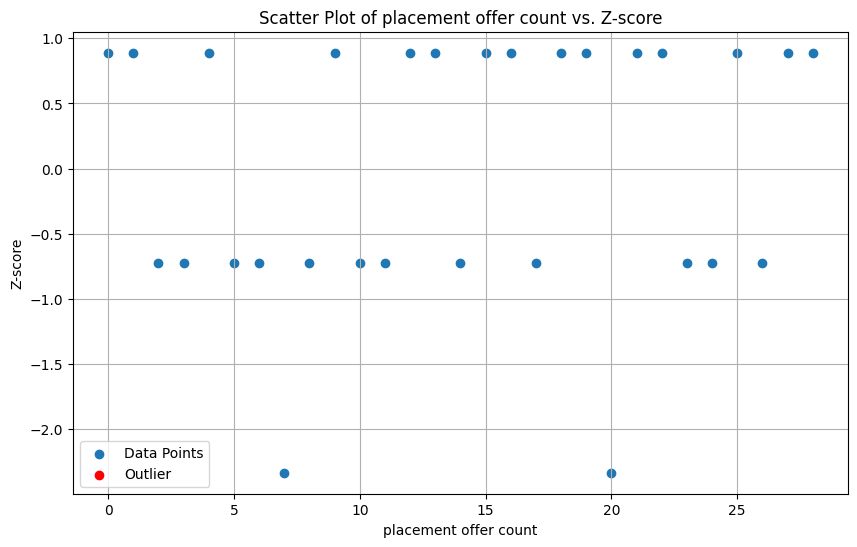

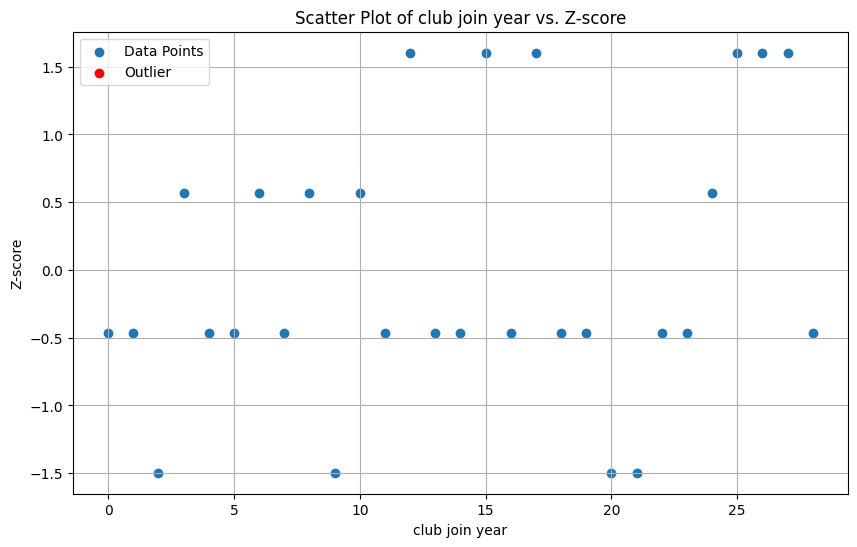

In [ ]:
from scipy.stats import zscore
for column_name in df.columns:
    # calculate z-score
    df['Z-score'] = zscore(df[column_name])

    # calculate outliers
    outliers = df[df['Z-score'].abs() > 3.0]

    # set figure size
    plt.figure(figsize=(10, 6))

    # print scatterplot
    plt.scatter(df[column_name].index, df['Z-score'], label='Data Points')
    plt.scatter(outliers[column_name].index, outliers['Z-score'], color='red', label='Outlier')

    plt.xlabel(column_name)
    plt.ylabel('Z-score')
    plt.title(f"Scatter Plot of {column_name} vs. Z-score")
    plt.legend()
    plt.grid(True)
    plt.show()

df.drop('Z-score', inplace=True, axis=1)


In [160]:
# Outlier handling via trimming
columns = df.columns
condition = (df[columns] >= lower_bound) & (df[columns] <= upper_bound)
mask = condition.all(axis=1)

cleaned_df = df[mask]

cleaned_df

,math score,reading score,writing score,placement score,placement offer count,club join year
0,80,68,70,89,3,2019
1,71,61,85,91,3,2019
4,78,71,67,90,3,2019
5,73,68,90,80,2,2019
8,76,60,79,77,2,2020
9,75,65,85,87,3,2018
12,80,80,78,94,3,2021
13,78,69,71,90,3,2019
15,78,62,79,93,3,2021
16,86,78,80,88,3,2019


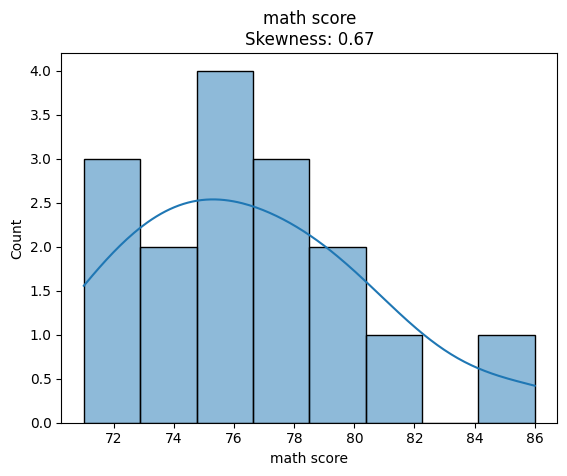

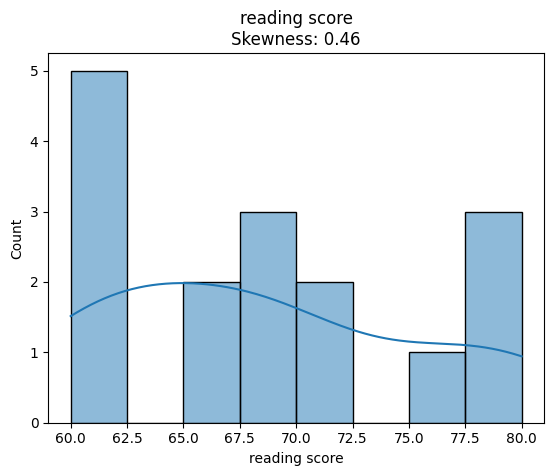

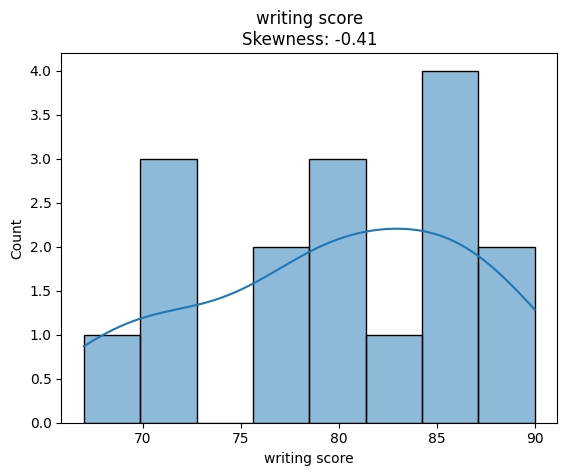

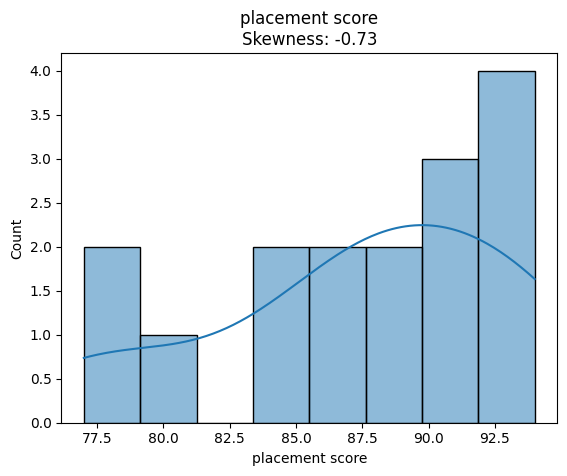

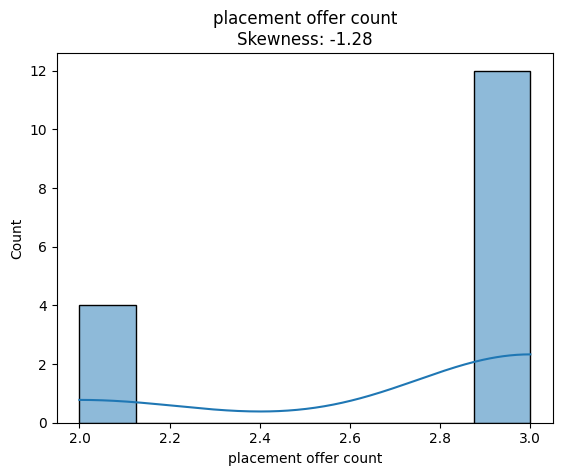

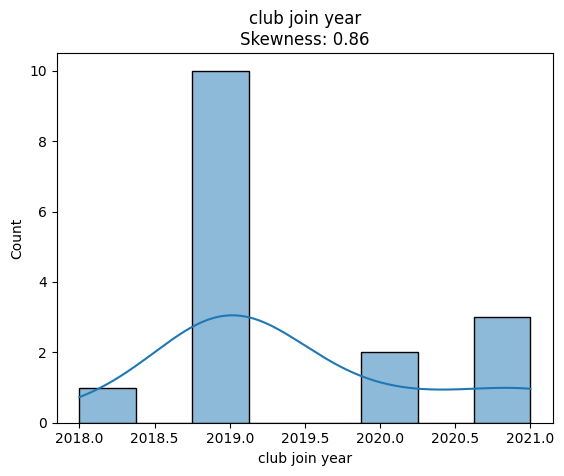

In [161]:
# print skewness of each column
for i, column_name in enumerate(cleaned_df.columns, 1):
    sns.histplot(cleaned_df[column_name], kde=True, bins=8)
    plt.title(f"{column_name}\nSkewness: {cleaned_df[column_name].skew():.2f}")
    plt.show()

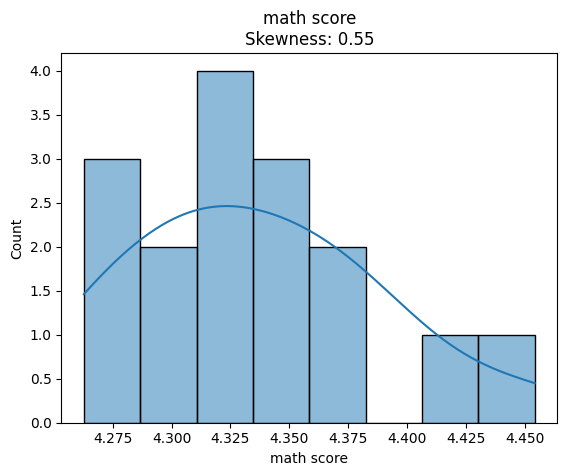

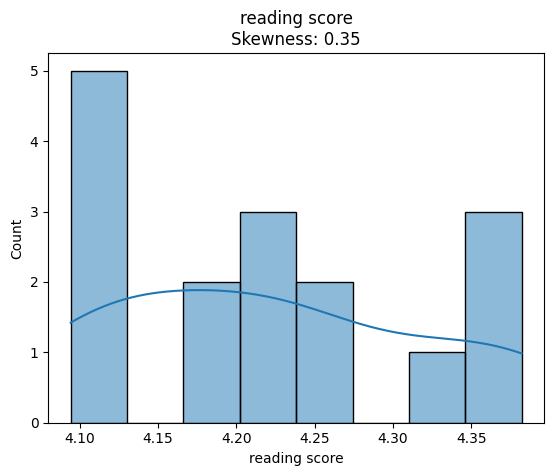

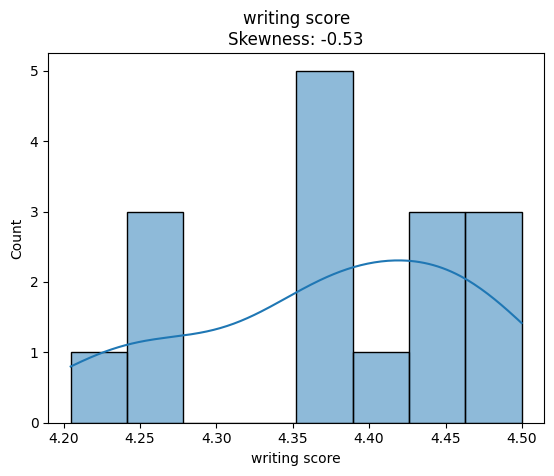

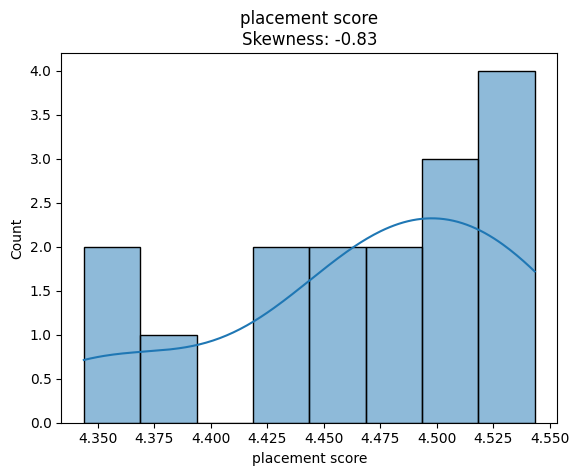

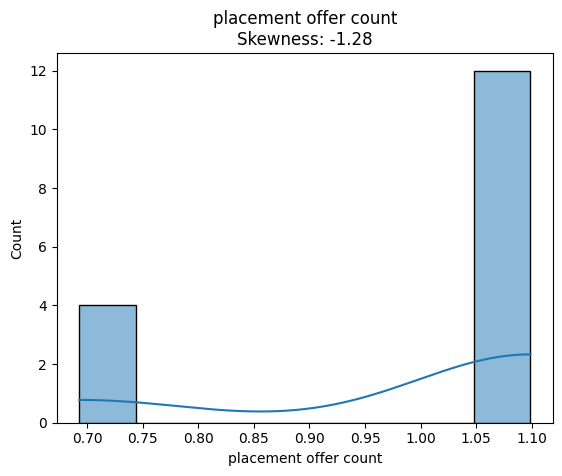

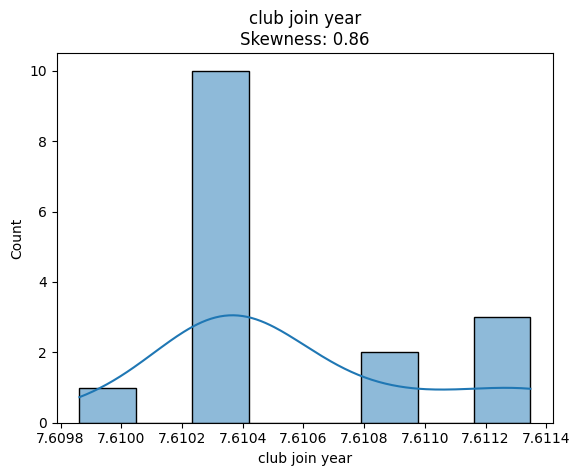

In [162]:
for column_name in cleaned_df:
    cleaned_df.loc[:, column_name] = np.log(cleaned_df[column_name])
    sns.histplot(cleaned_df[column_name], kde=True, bins=8)
    plt.title(f"{column_name}\nSkewness: {cleaned_df[column_name].skew():.2f}")
    plt.show()